# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [3]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [4]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

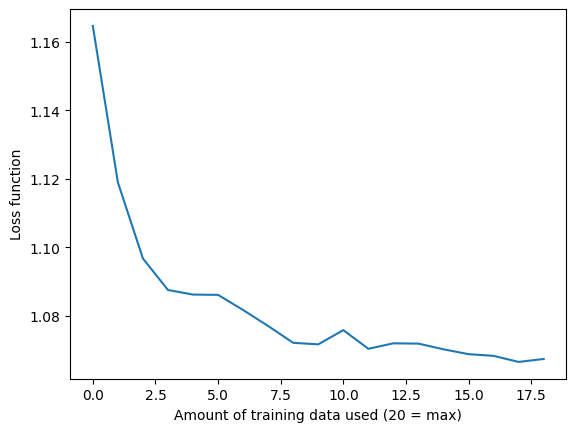

In [5]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [6]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

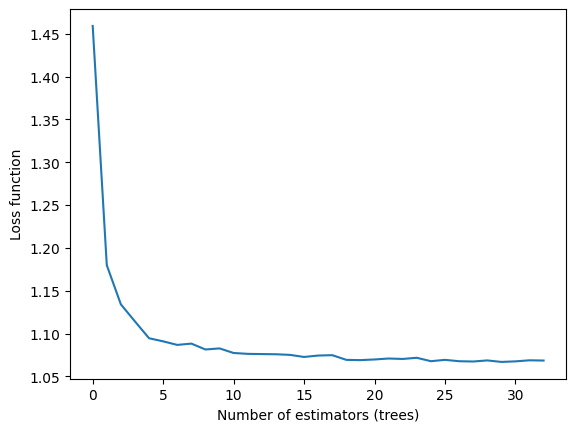

In [7]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [8]:
import os
import zipfile
import pandas as pd
import tempfile

# create temporary directory (not inside repo)
temp_dir = tempfile.gettempdir()
data_dir = os.path.join(temp_dir, "brazil_cancer_data")

os.makedirs(data_dir, exist_ok=True)

zip_path = os.path.join(data_dir, "cancer-data-brazil.zip")
csv_path = os.path.join(data_dir, "cancer_data_eng.csv")

# download if not already present
if not os.path.exists(csv_path):

    os.system(f"kaggle datasets download joaopedromedeiros/cancer-data-brazil -p {data_dir}")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(data_dir)

df = pd.read_csv(csv_path, encoding="ISO-8859-1")

print(df.head())

/tmp/ipykernel_60768/4070786109.py:23: DtypeWarning: Columns (0: Date.of.Birth, 1: Raca.Color, 2: Nationality, 3: Naturality.State, 4: Naturality, 5: Degree.of.Education, 6: State.Civil, 7: Status.Address, 8: City.Address, 9: Youth.Adult.Illness.Description, 10: Code.of.Disease.Adult.Young., 11: Indicator.of.Rare.Case, 12: Extension, 13: Laterality, 14: Statement, 15: TNM, 16: Status.Vital, 17: Type.of.Death, 18: Date.of.Death, 19: Date.of.Last.Contact, 20: Date.of.Diagnostic, 21: Distant.metastasis) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, encoding="ISO-8859-1")


   Patient.Code              RCBP.Name     Gender Date.of.Birth   Age  \
0      672054.0  RCBP CAMPINAS-UNICAMP  MASCULINO    1975-03-16  30.0   
1      673213.0  RCBP CAMPINAS-UNICAMP   FEMININO    1950-05-24  53.0   
2      673396.0  RCBP CAMPINAS-UNICAMP   FEMININO    1951-09-02  51.0   
3      673425.0  RCBP CAMPINAS-UNICAMP   FEMININO    1929-11-21  73.0   
4      673745.0  RCBP CAMPINAS-UNICAMP  MASCULINO    1934-07-03  71.0   

  Raca.Color Nationality Naturality.State Naturality Degree.of.Education  ...  \
0     BRANCO      BRASIL        SÃO PAULO        NaN                 NaN  ...   
1        NaN         NaN              NaN        NaN                 NaN  ...   
2      PARDA      BRASIL        SÃO PAULO        NaN                 NaN  ...   
3        NaN         NaN              NaN        NaN                 NaN  ...   
4     BRANCO      BRASIL        SÃO PAULO        NaN                 NaN  ...   

  Laterality  Statement  TNM Status.Vital Type.of.Death Date.of.Death  \
0

In [9]:
df["Date.of.Birth"] = pd.to_datetime(df["Date.of.Birth"], errors="coerce")
df["Date.of.Diagnostic"] = pd.to_datetime(df["Date.of.Diagnostic"], errors="coerce")

df.loc[df["Age"] >= 116, "Age"] = None
df.loc[df["Age"] <= 0, "Age"] = None


df.loc[
    df["Date.of.Birth"].isna() & df["Age"].notna(),
    "Date.of.Birth"
] = df["Date.of.Diagnostic"] - pd.to_timedelta(df["Age"] * 365.25, unit="D")

df[["Age", "Date.of.Birth"]].isnull().sum()

columns_encode = [
    "Gender",
    "Raca.Color",
    "Nationality",
    "Degree.of.Education",
    "State.Civil",
    "Status.Address",
    "Indicator.of.Rare.Case",
    "Diagnostic.means",
    "Extension",
    "Laterality",
    "Statement",
    "Status.Vital",
    "Type.of.Death",
]

df_encoded = pd.get_dummies(df, columns=columns_encode, drop_first=True)

In [10]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns

numeric_cols, categorical_cols

/tmp/ipykernel_60768/283104828.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns


(Index(['Patient.Code', 'Age', 'Code.Profession', 'Code.of.Morphology', 'year'], dtype='str'),
 Index(['RCBP.Name', 'Gender', 'Raca.Color', 'Nationality', 'Naturality.State',
        'Naturality', 'Degree.of.Education', 'State.Civil', 'Name.Occupation',
        'Status.Address', 'City.Address', 'Description.of.Topography',
        'Topography.Code', 'Morphology.Description', 'Description.of.Disease',
        'Illness.Code', 'Child.Illness.Description', 'Child.Illness.Code',
        'Youth.Adult.Illness.Description', 'Code.of.Disease.Adult.Young.',
        'Indicator.of.Rare.Case', 'Diagnostic.means', 'Extension', 'Laterality',
        'Statement', 'TNM', 'Status.Vital', 'Type.of.Death', 'Date.of.Death',
        'Date.of.Last.Contact', 'Distant.metastasis'],
       dtype='str'))

In [11]:
print(df["Status.Vital"].value_counts(dropna=False))

Status.Vital
NaN      1568418
MORTO     123862
VIVO       85896
Name: count, dtype: int64


In [12]:
df_ml = df[df["Status.Vital"].isin(["MORTO", "VIVO"])].copy()

In [13]:
df_ml["Status.Vital"] = df_ml["Status.Vital"].map({
    "VIVO": 0,
    "MORTO": 1
})

In [14]:
keep_cols = [
    "Age",
    "Gender",
    "Raca.Color",
    "Degree.of.Education",
    "State.Civil",
    "Diagnostic.means",
    "Extension",
    "Laterality",
    "Distant.metastasis",
    "year"
]

df_ml = df_ml.sample(50000, random_state=42)

X = df_ml[keep_cols]
y = df_ml["Status.Vital"]

In [15]:
X = pd.get_dummies(X, drop_first=True)

In [16]:
print(X.shape)

(50000, 244)


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

# Model
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predict
pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.83776
[[4449  673]
 [1355 6023]]
              precision    recall  f1-score   support

           0       0.77      0.87      0.81      5122
           1       0.90      0.82      0.86      7378

    accuracy                           0.84     12500
   macro avg       0.83      0.84      0.84     12500
weighted avg       0.85      0.84      0.84     12500



In [18]:
imp = pd.Series(rf.feature_importances_, index=X.columns)
print(imp.sort_values(ascending=False).head(15))

Diagnostic.means_SDO                                  0.252183
Diagnostic.means_HISTOLOGIA DO TUMOR PRIMÁRIO         0.211004
year                                                  0.145993
Laterality_NÃO SE APLICA                              0.113956
Extension_LOCALIZADO                                  0.050493
Extension_METÁSTASE                                   0.039233
Age                                                   0.030450
Raca.Color_PARDA                                      0.022740
State.Civil_VIÚVO                                     0.019132
Laterality_ESQUERDA                                   0.017641
Degree.of.Education_SEM ESCOLARIDADE                  0.012879
Laterality_DIREITA                                    0.012753
Gender_MASCULINO                                      0.009917
Degree.of.Education_FUNDAMENTAL II (5ª A 8ª SÉRIE)    0.007226
Raca.Color_BRANCO                                     0.006581
dtype: float64


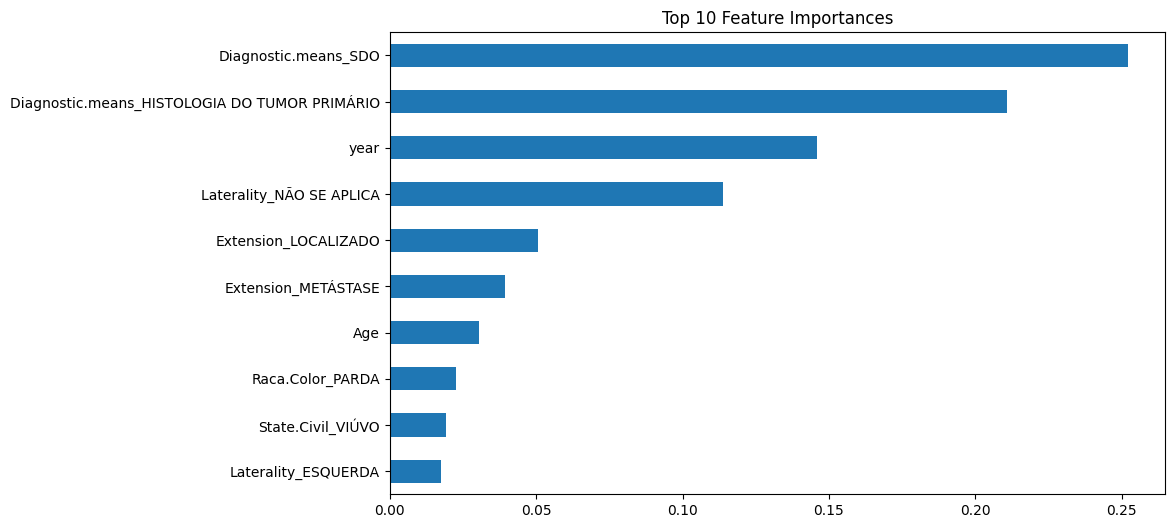

In [19]:
imp.sort_values().tail(10).plot(kind="barh", figsize=(10,6))
plt.title("Top 10 Feature Importances")
plt.show()

In [20]:
#Recall Cancer over time Dataset

df2 = pd.read_excel("Cancer Over Time.xlsx")
df2_1 = pd.read_excel("Cancer Over Time.xlsx", sheet_name="USA By Year")
df2_2 = pd.read_excel("Cancer Over Time.xlsx", sheet_name="Populations")

df1_long = df2_1.melt(
    id_vars=["Year", "Number"],
    var_name="Age_Group",
    value_name="Cancer_Cases"
)

df1_long["Age_Group"] = df1_long["Age_Group"].astype(int)

In [21]:
df2.columns = df2.columns.astype(str)

y = df2["Number"]

X = df2.drop(columns=["Population", "Number"])

In [22]:
X["Coverage"] = pd.to_numeric(X["Coverage"], errors="coerce")

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [24]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [25]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 4285558.154617669
R²: 0.9181834857602219


In [26]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf, X, y,
    cv=5,
    scoring="r2"
)

print(scores)
print(scores.mean())

[0.98961426 0.99363768 0.95378743 0.98790908 0.90058772]
0.9651072340242486


In [27]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

params = {
    "n_estimators": randint(100,400),
    "max_depth": randint(3,20),
    "min_samples_split": randint(2,8)
}

search = RandomizedSearchCV(
    rf,
    params,
    n_iter=10,
    cv=3,
    scoring="r2",
    random_state=42
)

search.fit(X_train, y_train)

print(search.best_params_)

{'max_depth': 14, 'min_samples_split': 2, 'n_estimators': 148}


In [28]:
rf_best = RandomForestRegressor(
    n_estimators=148,
    max_depth=14,
    min_samples_split=2,
    random_state=42
)

rf_best.fit(X_train, y_train)
pred = rf_best.predict(X_test)

In [29]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 4085353.9278413677
R²: 0.9256492145629855


# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

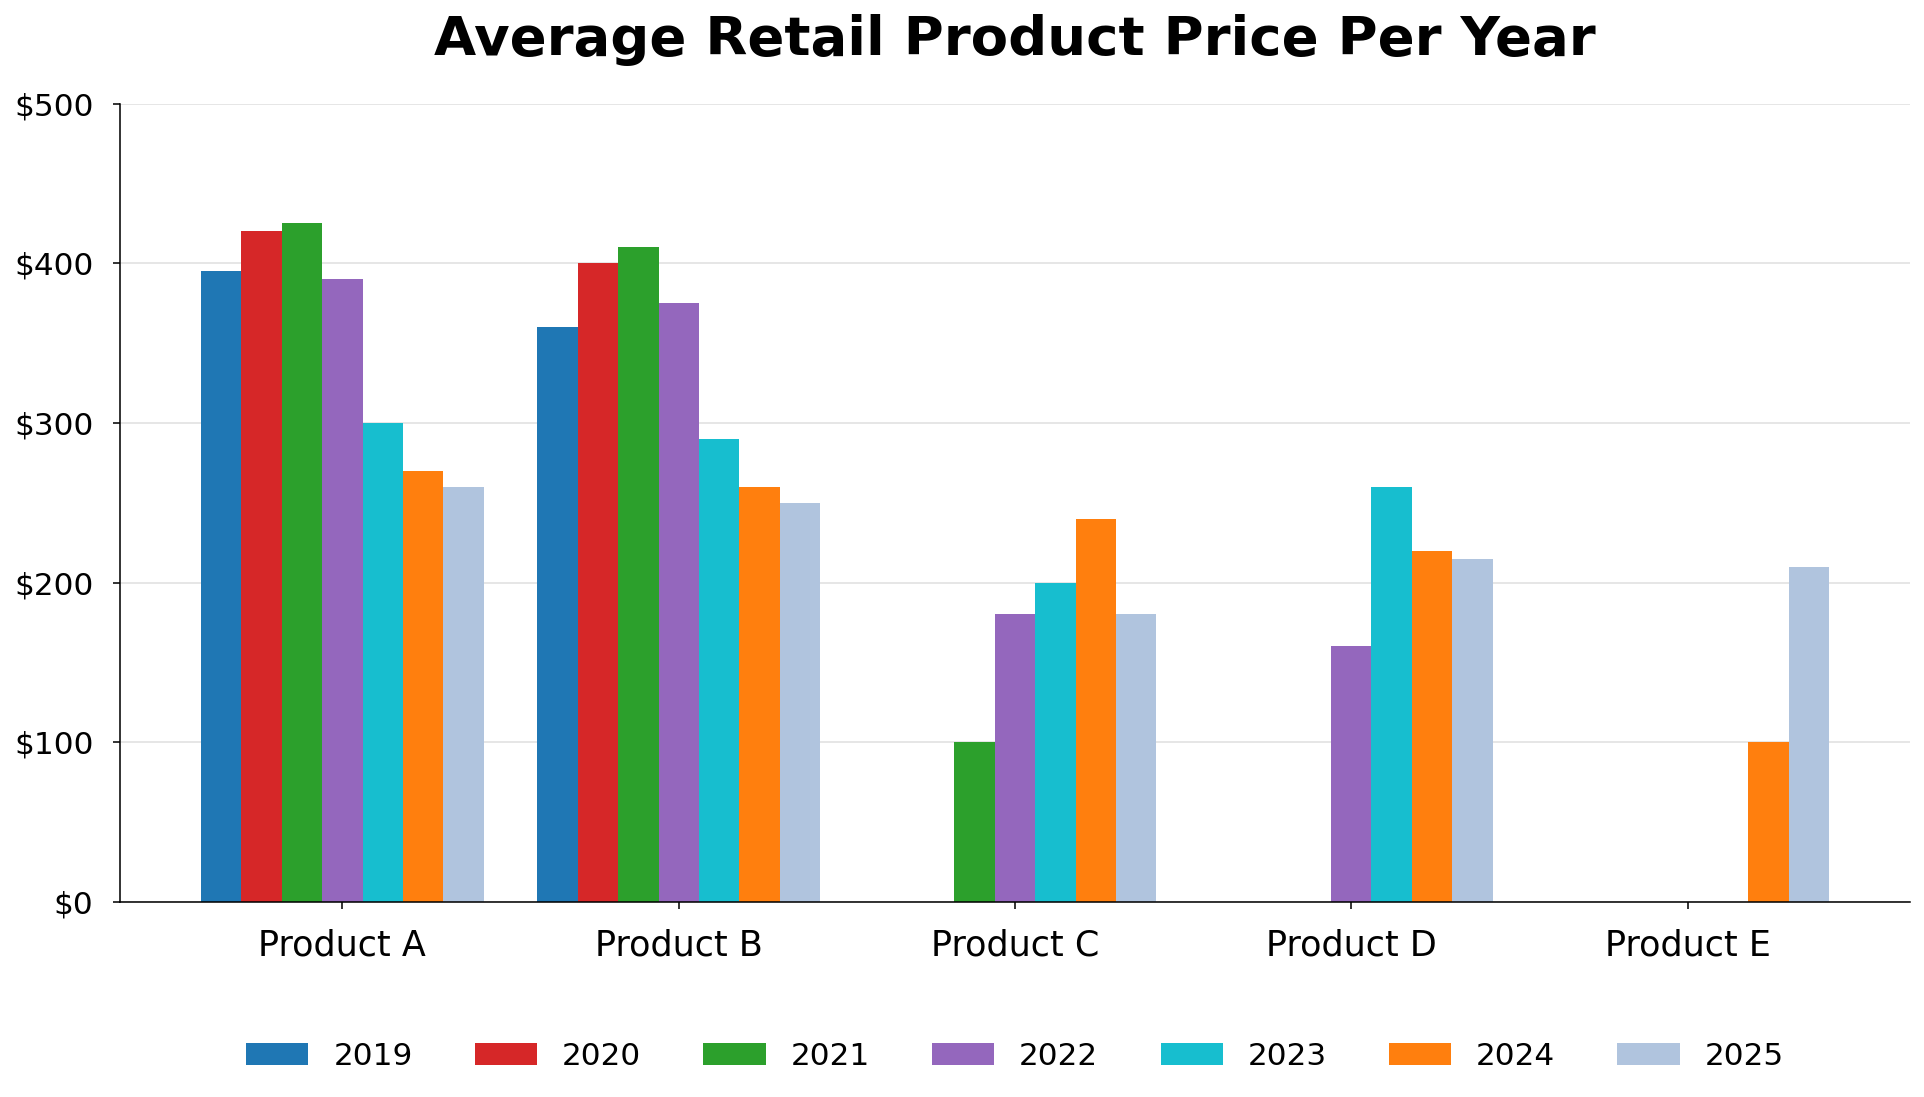

In [30]:
products = ["Product A", "Product B", "Product C", "Product D", "Product E"]

data = {
    "2019": [395, 360,   0,   0,   0],
    "2020": [420, 400,   0,   0,   0],
    "2021": [425, 410, 100,   0,   0],
    "2022": [390, 375, 180, 160,   0],
    "2023": [300, 290, 200, 260,   0],
    "2024": [270, 260, 240, 220, 100],
    "2025": [260, 250, 180, 215, 210],
}

years = list(data.keys())

colors = [
    "tab:blue",
    "tab:red",
    "tab:green",
    "tab:purple",
    "tab:cyan",
    "tab:orange",
    "lightsteelblue"
]


x = np.arange(len(products))
bar_width = 0.12

fig, ax = plt.subplots(figsize=(14,8), dpi=140)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")


for i, year in enumerate(years):
    ax.bar(
        x + (i - 3) * bar_width,
        data[year],
        width=bar_width,
        label=year,
        color=colors[i],
        edgecolor="none"
    )

ax.set_title(
    "Average Retail Product Price Per Year",
    fontsize=28,
    weight="bold",
    pad=25
)


ax.set_xticks(x)
ax.set_xticklabels(products, fontsize=18)

ax.set_ylim(0, 500)
ax.set_yticks(np.arange(0, 501, 100))
ax.set_yticklabels([f"${v}" for v in range(0, 501, 100)], fontsize=16)

# Gridlines
ax.grid(axis="y", alpha=0.4)
ax.set_axisbelow(True)

# Spines
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis='x', pad=10)
ax.tick_params(axis='y', pad=10)

ax.legend(
    ncol=7,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    frameon=False,
    fontsize=16
)

plt.tight_layout()
plt.show()